In [1]:
import numpy as np
import pandas as pd

url = "https://raw.githubusercontent.com/prof-dana/Lecture-Code/refs/heads/main/AdvancedMachineLearning/data/auto-mpg.csv"
data_df = pd.read_csv(url)

print('데이터셋 크기: ', data_df.shape)
data_df.head()

데이터셋 크기:  (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [2]:
data_df = data_df.drop(['car_name', 'origin', 'horsepower'], axis = 1, inplace = False)
data_df.head()  #작업 확인용 출력

,mpg,cylinders,displacement,weight,acceleration,model_year
0,18.0,8,307.0,3504,12.0,70
1,15.0,8,350.0,3693,11.5,70
2,18.0,8,318.0,3436,11.0,70
3,16.0,8,304.0,3433,12.0,70
4,17.0,8,302.0,3449,10.5,70


In [3]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 18.8 KB


In [4]:
#X, Y 분할하기
Y = data_df['mpg']
X = data_df.drop(['mpg'], axis = 1, inplace = False)

print(X.shape)
print(Y.shape)

(398, 5)
(398,)


In [5]:
from sklearn.model_selection import train_test_split
#훈련용 데이터와 평가용 데이터 분할하기
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 0)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(278, 5)
(120, 5)
(278,)
(120,)


In [6]:
from sklearn.linear_model import LinearRegression

#선형 회귀 분석 : 모델 생성
lr = LinearRegression()

#선형 회귀 분석 : 모델 훈련
lr.fit(X_train, Y_train)

LinearRegression()

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#선형 회귀 분석 : 평가 데이터에 대한 예측 수행 -> 예측 결과 Y_predict 구하기
Y_predict = lr.predict(X_test)

#평가 지표
mae = mean_absolute_error(Y_test, Y_predict)
mse = mean_squared_error(Y_test, Y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_predict)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2.690257264217133
MSE: 12.27823903660951
RMSE: 3.504031825855683
R2: 0.8078579451877163


In [8]:
print('Y 절편 값: ', np.round(lr.intercept_, 2))
print('회귀 계수 값: ', np.round(lr.coef_, 2))

Y 절편 값:  -17.55
회귀 계수 값:  [-0.14  0.01 -0.01  0.2   0.76]


In [9]:
coef = pd.Series(data = np.round(lr.coef_, 2), index = X.columns)
coef

cylinders      -0.14
displacement    0.01
weight         -0.01
acceleration    0.20
model_year      0.76
dtype: float64

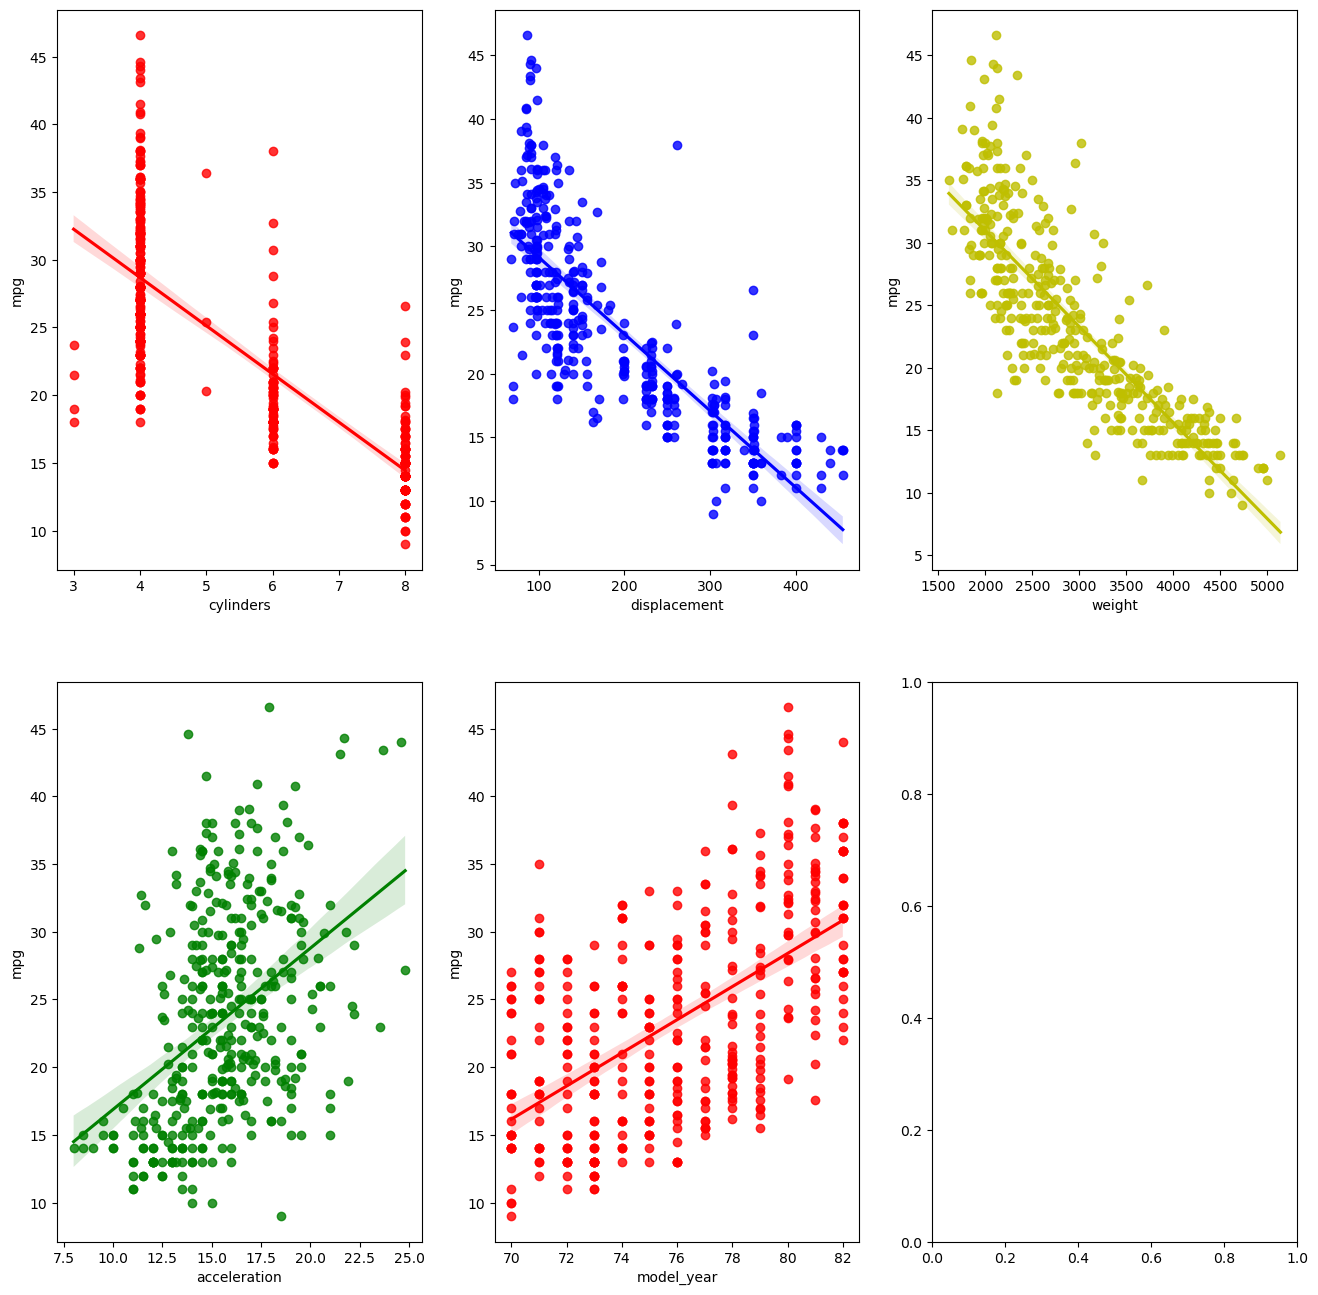

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(figsize = (16, 16), nrows = 2, ncols = 3) #크기설정
plot_color = ['r', 'b', 'y', 'g', 'r'] #color 설정

for i, feature in enumerate(X.columns):
    #위치 지정
    row = int(i/3)
    col = i%3    
    
    sns.regplot(x = feature, y = 'mpg', data = data_df, ax = axs[row][col], color = plot_color[i])

plt.show()

In [11]:
#연비를 예측하고 싶은 차의 정보
cylinders = 8
displacement = 350
weight = 3200
acceleration = 22
model_year = 99

info = np.array([[cylinders, displacement, weight, acceleration, model_year]])
mpg_predict = lr.predict(info)

print("이 자동차의 예상 연비(MPG)는 %.2f입니다." % mpg_predict)

이 자동차의 예상 연비(MPG)는 41.32입니다.


C:\Users\DANA-LAB\.conda\envs\ml\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\DANA-LAB\AppData\Local\Temp\ipykernel_41404\2096799839.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("이 자동차의 예상 연비(MPG)는 %.2f입니다." % mpg_predict)


In [12]:
url = "https://raw.githubusercontent.com/prof-dana/Lecture-Code/refs/heads/main/AdvancedMachineLearning/data/dustdata_20220401_20240215.csv"

data_df =  pd.read_csv(url)
print(data_df.shape)
data_df.head()   #작업 확인용 출력

(673, 7)


,day,so2,co,o3,no2,pm10,pm25
0,2022-04-01,0.003,0.4,0.034,0.017,15,10
1,2022-04-02,0.004,0.4,0.036,0.022,30,19
2,2022-04-03,0.004,0.5,0.041,0.024,43,30
3,2022-04-04,0.004,0.6,0.040,0.029,57,41
4,2022-04-05,0.004,0.5,0.044,0.032,43,29


In [13]:
data_df.isnull().sum()

day     0
so2     7
co      0
o3      0
no2     0
pm10    0
pm25    0
dtype: int64

In [14]:
data_df = data_df.fillna(data_df['so2'].median())
data_df.isnull().sum()  #작업 결과 확인

day     0
so2     0
co      0
o3      0
no2     0
pm10    0
pm25    0
dtype: int64

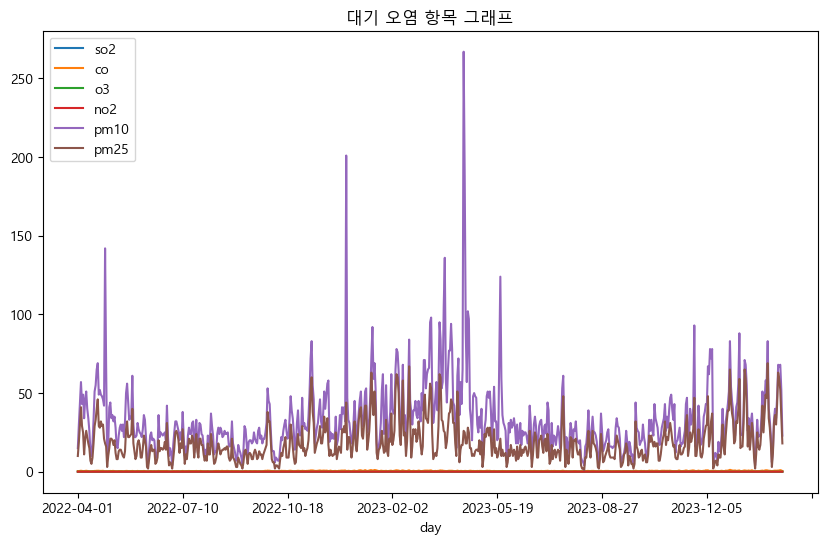

In [15]:
import matplotlib
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')

data_df.set_index('day',inplace=True)
data_df.plot(kind='line', figsize=(10, 6))  # kind='line'으로 선형 그래프 지정

plt.title('대기 오염 항목 그래프')  
plt.xlabel('day')  # x 축 레이블 설정
plt.legend(loc='upper left')  # 범례 위치 설정
plt.show()  

In [16]:
data_df

,so2,co,o3,no2,pm10,pm25
day,,,,,,
2022-04-01,0.003,0.4,0.034,0.017,15,10
2022-04-02,0.004,0.4,0.036,0.022,30,19
2022-04-03,0.004,0.5,0.041,0.024,43,30
2022-04-04,0.004,0.6,0.040,0.029,57,41
2022-04-05,0.004,0.5,0.044,0.032,43,29
...,...,...,...,...,...,...
2024-02-11,0.003,0.7,0.037,0.026,68,63
2024-02-12,0.003,0.8,0.024,0.046,67,59
2024-02-13,0.003,1.0,0.017,0.069,68,52


In [17]:
from sklearn.preprocessing import StandardScaler


data_scaled = StandardScaler().fit_transform(data_df.values)
data_df2 = pd.DataFrame(data_scaled)
data_df2.columns = ['so2','co','o3','no2','pm10','pm25']

data_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 673 entries, 0 to 672
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   so2     673 non-null    float64
 1   co      673 non-null    float64
 2   o3      673 non-null    float64
 3   no2     673 non-null    float64
 4   pm10    673 non-null    float64
 5   pm25    673 non-null    float64
dtypes: float64(6)
memory usage: 31.7 KB


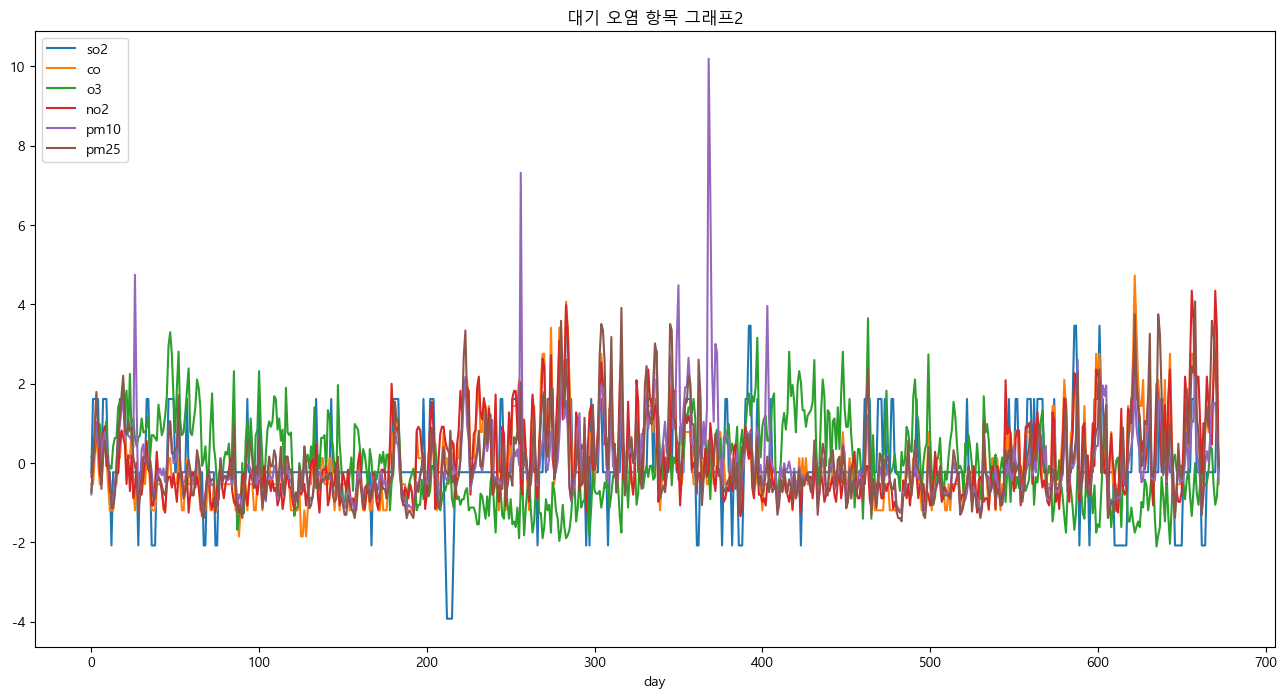

In [18]:
data_df2.plot(kind='line', figsize=(16, 8))  
plt.title('대기 오염 항목 그래프2')  
plt.xlabel('day')  
plt.legend(loc='upper left')  
plt.rcParams['axes.unicode_minus'] = False   #음수 부호 깨지지 않게 설정 
plt.show() 

In [19]:
# X, Y 분할하기
Y_pm10 = data_df['pm10']
Y_pm25 = data_df['pm25']
X = data_df.drop(['pm10', 'pm25'], axis=1)

print(Y_pm10.shape)
print(Y_pm25.shape)
print(X.shape)

(673,)
(673,)
(673, 4)


In [20]:
# 훈련용 데이터와 평가용 데이터 분할하기
X10_train, X10_test, Y_pm10_train, Y_pm10_test = train_test_split(X, Y_pm10, test_size=0.3, random_state=156)
X25_train, X25_test, Y_pm25_train, Y_pm25_test = train_test_split(X, Y_pm25, test_size=0.3, random_state=156)

print(X10_train.shape)
print(X10_test.shape)
print(Y_pm10_train.shape)
print(Y_pm10_test.shape)
print("*"*20)
print(X25_train.shape)
print(X25_test.shape)
print(Y_pm25_train.shape)
print(Y_pm25_test.shape)

(471, 4)
(202, 4)
(471,)
(202,)
********************
(471, 4)
(202, 4)
(471,)
(202,)


In [21]:
# 선형회귀분석 : 모델 생성
lr_pm10 = LinearRegression()
lr_pm25 = LinearRegression()

# 선형회귀분석 : 모델 훈련
lr_pm10.fit(X10_train, Y_pm10_train)
lr_pm25.fit(X25_train, Y_pm25_train)

LinearRegression()

In [22]:
# 선형회귀분석 : 평가 데이터에 대한 예측 수행 -> 예측 결과 Y_predict 구하기
Y_pm10_predict = lr_pm10.predict(X10_test)
Y_pm25_predict = lr_pm25.predict(X25_test)

print("미세먼지 예측값 예시:",Y_pm10_predict[:5])
print("초미세먼지 예측값 예시:",Y_pm25_predict[:5])

미세먼지 예측값 예시: [21.29304238 53.74171521 32.79177469 36.36253429 44.77892892]
초미세먼지 예측값 예시: [ 7.13220945 31.68218802 19.08019538 20.41887987 25.70310147]


In [23]:
#미세먼지 평가 지표
mae10 = mean_absolute_error(Y_pm10_test, Y_pm10_predict)
mae25 = mean_absolute_error(Y_pm25_test, Y_pm25_predict)

mse10 = mean_squared_error(Y_pm10_test, Y_pm10_predict)
mse25 = mean_squared_error(Y_pm25_test, Y_pm25_predict)

rmse10 = np.sqrt(mse10)
rmse25 = np.sqrt(mse25)

r2_10 = r2_score(Y_pm10_test, Y_pm10_predict)
r2_25 = r2_score(Y_pm25_test, Y_pm25_predict)


print("MAE:", mae10, mae25)
print("MSE:", mse10, mse25)
print("RMSE:", rmse10, rmse25)
print("R2:", r2_10,r2_25)

MAE: 9.959734530853407 5.188757730730706
MSE: 293.3674588043666 51.813164285392745
RMSE: 17.12797299169889 7.198136167466738
R2: 0.34405245682645136 0.6611532166319251


In [24]:
print('Y_pm10 절편 값: ', lr_pm10.intercept_)
print('회귀 계수 값: ', np.round(lr_pm10.coef_, 1))

print('Y_pm25 절편 값: ', lr_pm25.intercept_)
print('회귀 계수 값: ', np.round(lr_pm25.coef_, 1))

Y_pm10 절편 값:  -24.637204220135388
회귀 계수 값:  [2512.8   55.2  444.8  447.3]
Y_pm25 절편 값:  -22.95245987117543
회귀 계수 값:  [776.   61.5 218.2 136.8]


In [25]:
coef10 = pd.Series(data = np.round(lr_pm10.coef_, 2), index=X.columns)
coef25 = pd.Series(data = np.round(lr_pm25.coef_, 2), index=X.columns)

print(coef10)
print("*"*15)
print(coef25)

so2    2512.75
co       55.18
o3      444.80
no2     447.27
dtype: float64
***************
so2    776.01
co      61.50
o3     218.18
no2    136.83
dtype: float64


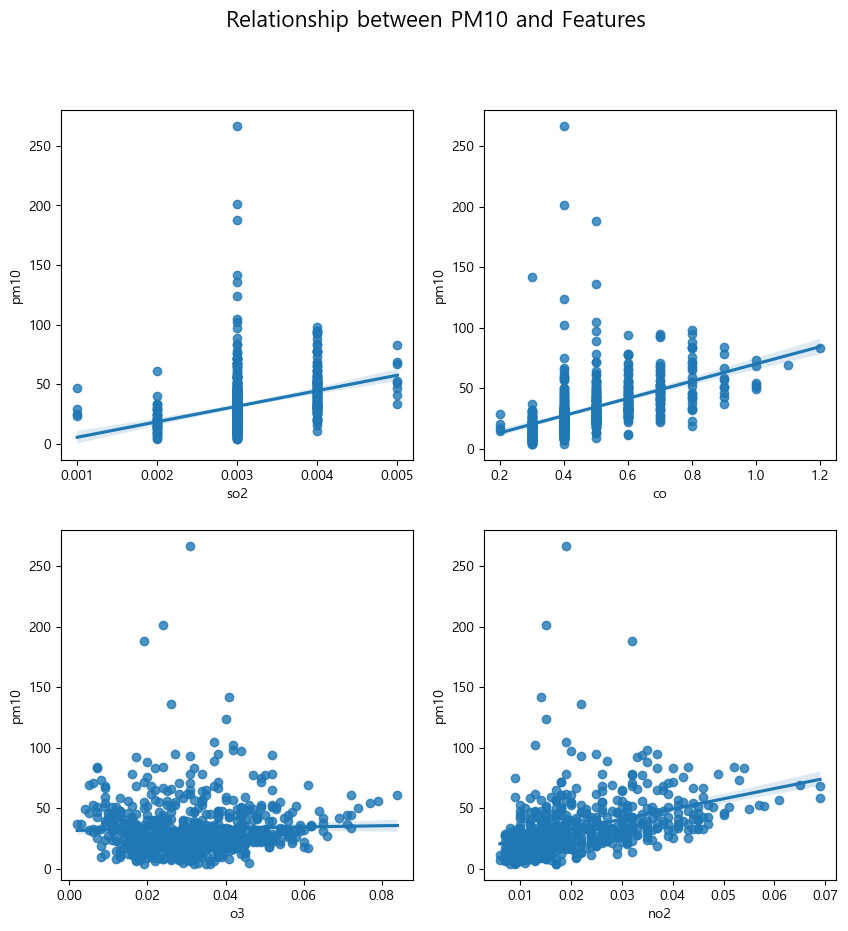

In [26]:
fig, axs = plt.subplots(figsize=(10, 10), ncols=2, nrows=2)

for i, feature in enumerate(X.columns):
      row = int(i/2)
      col = i%2
      sns.regplot(x=feature, y='pm10', data=data_df, ax=axs[row][col])
    
fig.suptitle("Relationship between PM10 and Features", fontsize=16)
plt.show()

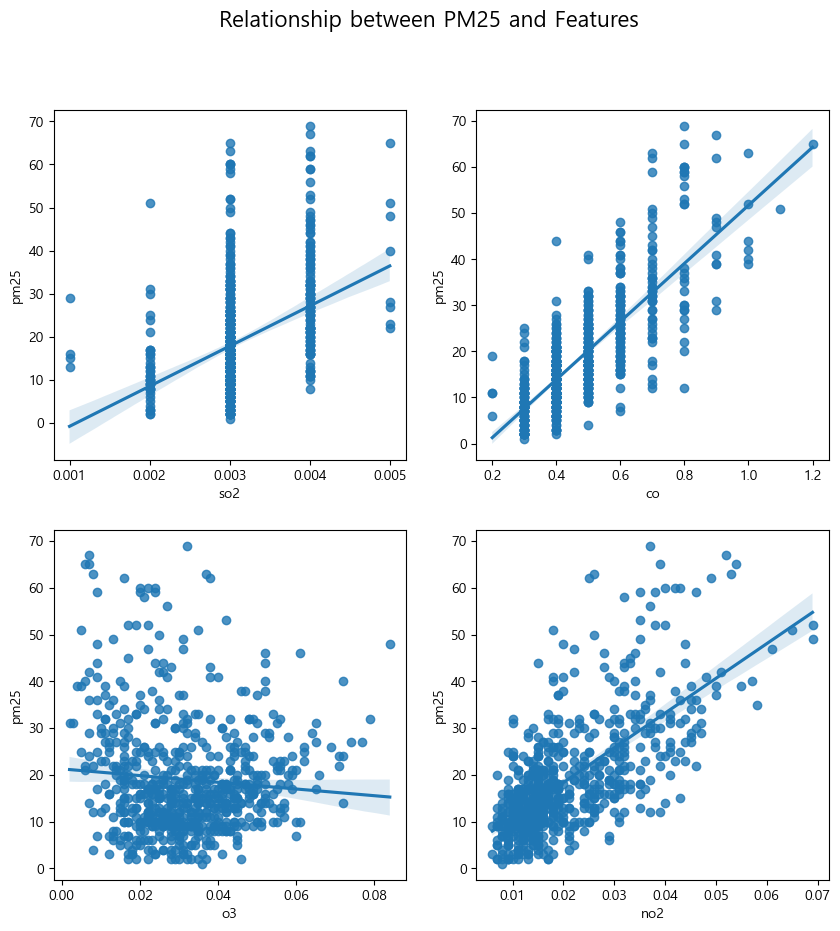

In [27]:
fig, axs = plt.subplots(figsize=(10, 10), ncols=2, nrows=2)

for i, feature in enumerate(X.columns):
      row = int(i/2)
      col = i%2
      sns.regplot(x=feature, y='pm25', data=data_df, ax=axs[row][col])

fig.suptitle("Relationship between PM25 and Features", fontsize=16)
plt.show()